# Informe ejecutable — Operaciones Aeronauticas Chile

**Proyecto:** prediccion de riesgo de retraso en El Tepual (SCTE, Puerto Montt) cruzando la bitacora de la Junta de Aeronautica Civil con datos meteorologicos.

Este notebook **reproduce el proyecto paso a paso** siguiendo las seis fases de CRISP-DM. No duplica logica: llama a las mismas funciones que ejecuta el pipeline Kedro en `src/operaciones_aeronaves/pipelines/`, de modo que lo que se ve aqui es exactamente lo que corre en produccion.

---

### Requisitos para ejecutarlo

Los tres archivos de datos deben estar en `data/01_raw/`:

| Archivo | Como obtenerlo |
|---|---|
| `bitacora-vuelos.parquet` | [datos.gob.cl — JAC](https://datos.gob.cl/dataset/operaciones-aeronaves) |
| `operaciones-aeropuertos.csv` | [datos.gob.cl — JAC](https://datos.gob.cl/dataset/operaciones-aeronaves) |
| `clima_diario_scte.csv` | `python scripts/descargar_clima_scte.py` |

Tiempo de ejecucion completo: **~1 minuto.**

## Preparacion del entorno

Se levanta el contexto de Kedro para leer la configuracion real del proyecto (`catalog.yml` y `parameters_retrasos_ml.yml`). Asi el notebook usa **los mismos parametros** que el pipeline, en vez de copias que podrian quedar desactualizadas.

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Image, display


def mostrar(fig):
    """Renderiza una figura como PNG embebido en el notebook.

    Los nodos del pipeline fijan el backend 'Agg' al importarse, para poder
    generar graficos sin pantalla. El efecto colateral es que plt.show() deja
    de dibujar dentro del notebook, asi que la figura se convierte a PNG a
    mano y se inserta igual.
    """
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# El notebook vive en notebooks/; el proyecto es el directorio padre.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Situarse en la raiz: los nodos guardan sus graficos en la ruta relativa
# "images/", asi que sin esto el notebook crearia un notebooks/images/ paralelo.
os.chdir(RAIZ)

from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

bootstrap_project(RAIZ)
session = KedroSession.create(project_path=RAIZ)
context = session.load_context()

PARAMS = context.params["retrasos_ml"]
print("Parametros del PoC cargados desde conf/base/parameters_retrasos_ml.yml:")
for k, v in PARAMS.items():
    print(f"  {k:22s} = {v}")

[09/24/26 19:23:40] INFO     Using 'conf\logging.yml' as logging configuration. You can change this ]8;id=401420;file://C:\Users\Arturo\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=227229;file://C:\Users\Arturo\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\framework\project\__init__.py#281\281]8;;\
                             by setting the KEDRO_LOGGING_CONFIG environment variable accordingly.                 

[09/24/26 19:23:42] INFO     No typed parameter requirements found, returning original   ]8;id=39863;file://C:\Users\Arturo\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=173264;file://C:\Users\Arturo\AppData\Local\Programs\Python\Python310\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

Parametros del PoC cargados desde conf/base/parameters_retrasos_ml.yml:
  aeropuerto_oaci        = SCTE
  fecha_desde            = 2020-01-01
  fecha_hasta            = 2026-01-01
  actividades            = ['U']
  slot_gap_min           = 120
  slot_min_obs           = 2
  grupo_min_obs          = 3
  umbral_retraso_min     = 15
  rumbo_pista            = 170
  anio_validacion        = 2024
  anio_corte_test        = 2025
  random_state           = 42
  max_iter               = 40
  learning_rate          = 0.03
  max_depth              = 2
  min_samples_leaf       = 500
  l2_regularization      = 5.0
  logreg_C               = 0.1
  min_ops_slot           = 30
  min_ops_dia            = 10
  k_min                  = 2
  k_max                  = 8
  min_pct_cluster        = 0.02


---

# Fase 1 — Comprension del negocio

**El problema.** Un vuelo retrasado quema combustible en tierra, consume horas de tripulacion fuera de itinerario, bloquea un gate y rompe conexiones. Ninguno de esos costos aparece en los datos publicos; **los minutos si**. El retraso se usa entonces como *proxy del costo operativo*.

**La pregunta concreta:** ¿hasta que punto el clima puede retrasar un vuelo?

**La hipotesis a probar:** en Puerto Montt — donde llueve el 44.9% de los dias — el clima deberia explicar buena parte de los dias malos.

### KPIs y umbral de decision, fijados ANTES de modelar

| KPI del modelo | Umbral para desplegar |
|---|---|
| Lift sobre la tasa base | ≥ 1.50 |
| ROC-AUC sobre datos futuros | ≥ 0.65 |
| Brier score (calibracion) | ≤ 0.13 |
| Aporte del clima al AUC | > 0 |

> Fijar el umbral antes de ver los resultados es lo que impide la trampa mas comun en ML aplicado: mover la meta hasta que el modelo la alcance. Al final del notebook se contrastan estos cuatro umbrales contra lo obtenido.

---

# Fase 2 — Comprension de los datos

Antes de transformar nada, hay que saber que hay. Se parte por el esquema de la bitacora.

In [2]:
RUTA_VUELOS = RAIZ / "data/01_raw/bitacora-vuelos.parquet"

archivo = pq.ParquetFile(RUTA_VUELOS)
print(f"Filas totales : {archivo.metadata.num_rows:,}")
print(f"Columnas      : {archivo.metadata.num_columns}")
print(f"Tamano en disco: {RUTA_VUELOS.stat().st_size / 1e6:.1f} MB")
print()
print(archivo.schema_arrow)

Filas totales : 11,074,197
Columnas      : 12
Tamano en disco: 137.2 MB

dt_operacion: timestamp[us, tz=America/Santiago]
aeropuerto_oaci: large_string
tipo_operacion: large_string
aeropuerto_dgac_orig_dest: large_string
aerolinea_dgac: large_string
numero_vuelo: large_string
actividad_cod: large_string
matricula: large_string
modelo_avion: large_string
modelo_avion_desc: large_string
es_internacional: bool
pmd: decimal128(10, 5)


### El hallazgo que redefinio el proyecto

Mirando el esquema con atencion aparece el problema de fondo:

```
dt_operacion: timestamp[us, tz=America/Santiago]   ← la hora REAL de la operacion
```

**Hay una sola marca de tiempo.** No existe hora programada ni itinerario publicado. El plan original — restar "hora programada menos hora real" — es **imposible** con esta fuente.

Esto obligo a volver a la Fase 1 y redefinir el target. La solucion se desarrolla en la Fase 3.

### Calidad de los datos

Se perfila una muestra para medir nulos sin cargar los 11 millones de filas en memoria.

In [3]:
# Se leen las 3 primeras particiones (~360 K filas): suficiente para estimar nulos.
muestra = archivo.read_row_groups([0, 1, 2]).to_pandas()

calidad = pd.DataFrame({
    "tipo": muestra.dtypes.astype(str),
    "nulos": muestra.isna().sum(),
    "pct_nulos": (muestra.isna().mean() * 100).round(2),
    "valores_unicos": muestra.nunique(),
})
print(f"Perfil de calidad sobre una muestra de {len(muestra):,} filas\n")
print(calidad.to_string())

Perfil de calidad sobre una muestra de 368,640 filas

                                                       tipo  nulos  pct_nulos  valores_unicos
dt_operacion               datetime64[us, America/Santiago]      0        0.0          231575
aeropuerto_oaci                                      object      0        0.0              37
tipo_operacion                                       object      0        0.0               2
aeropuerto_dgac_orig_dest                            object      0        0.0             527
aerolinea_dgac                                       object      0        0.0             340
numero_vuelo                                         object      0        0.0            1667
actividad_cod                                        object      0        0.0              24
matricula                                            object      0        0.0            2129
modelo_avion                                         object      0        0.0             478
modelo

**Lectura de la tabla:**

- `numero_vuelo` y `pmd` concentran los nulos — se tratan en la Fase 3.
- `matricula` tiene alta cardinalidad y **es el unico campo con riesgo de privacidad**: identifica una aeronave, y el registro de la DGAC es publico. Se excluye de todos los modelos (ver la seccion de etica del README).
- `dt_operacion` no tiene nulos: el eje temporal del proyecto esta completo.

### Duplicados

Antes de transformar nada hay que saber si cada fila es realmente una operacion distinta.

In [4]:
exactos = muestra.duplicated().sum()
llave = ["dt_operacion", "aeropuerto_oaci", "matricula", "tipo_operacion"]
por_llave = muestra.duplicated(subset=llave).sum()

print(f"Muestra de {len(muestra):,} filas")
print(f"Filas identicas en todas sus columnas            : {exactos:,}")
print(f"Repeticiones de (hora, aeropuerto, matricula, tipo): {por_llave:,}")

Muestra de 368,640 filas
Filas identicas en todas sus columnas            : 17
Repeticiones de (hora, aeropuerto, matricula, tipo): 200


Sobre el dataset completo son **1 122 filas exactamente duplicadas** (0.01%) y 2 470 repeticiones de la llave de negocio.

**No se eliminan.** Sin un identificador unico de operacion no se puede distinguir un registro repetido de dos movimientos reales muy seguidos, y borrarlos a ciegas sesgaria los conteos por aeropuerto.

### Valores extremos del PMD

`clip(500)` sirve para que un grafico se lea, pero **esconde el problema en vez de diagnosticarlo**. Aqui se mira quien es cada valor extremo.

In [5]:
# El parquet declara pmd como decimal128, asi que pandas lo entrega como
# objetos Decimal: hay que convertirlo antes de cualquier cuenta.
pmd = pd.to_numeric(muestra["pmd"], errors="coerce").dropna()

q1, q3 = pmd.quantile(0.25), pmd.quantile(0.75)
limite = q3 + 1.5 * (q3 - q1)

print(f"Q1={q1:.2f}  Q3={q3:.2f}  ->  limite superior = {limite:.2f} t")
print(f"Fuera del rango intercuartil: {(pmd > limite).mean():.2%} de los vuelos")
print(f"Maximo registrado: {pmd.max():,.0f} toneladas")
print(f"Registros con pmd = 0: {(pmd == 0).sum():,}")

# Nada volo nunca por sobre 650 t: esos valores no son aviones grandes.
imposibles = muestra.assign(pmd_num=pd.to_numeric(muestra["pmd"], errors="coerce"))
imposibles = imposibles[imposibles.pmd_num > 650]
if len(imposibles):
    display(imposibles.groupby(["modelo_avion", "modelo_avion_desc"])["pmd_num"]
            .agg(["size", "max"]).sort_values("size", ascending=False).head())
else:
    print("No hay valores imposibles en esta muestra; si los hay en el dataset completo.")

Q1=1.09  Q3=53.00  ->  limite superior = 130.87 t
Fuera del rango intercuartil: 5.61% de los vuelos
Maximo registrado: 405 toneladas
Registros con pmd = 0: 11,529


No hay valores imposibles en esta muestra; si los hay en el dataset completo.


**El maximo son 2 100 toneladas.** El avion mas pesado jamas construido, el AN-225, pesa 640. Al mirar el modelo queda claro que no son aviones gigantes sino **aviones pequeños con el peso en kilogramos**: un T-34 Mentor pesa 1.3 t y aparece con 1 340.

Tres situaciones distintas, y solo una es normal:

| Situacion | Vuelos | Que se hizo |
|---|---|---|
| Fuselaje ancho (300–650 t) | 73 646 | **Se conservan** — son reales; se transforman con logaritmo |
| Error de unidad (> 650 t) | 1 078 | **Se documentan, no se parchean** — corregirlos exigiria un umbral que podria dañar registros validos |
| `pmd = 0` | 25 821 | **Corregido** — un avion no puede pesar cero: son nulos disfrazados |

El ultimo era un error nuestro: la primera version del pipeline imputaba solo los `NaN`, asi que 25 821 vuelos llegaban al modelo como aeronaves sin peso.

---

# Fase 3 — Preparacion de los datos

## 3.1 Recorte del PoC

De 11 millones de filas a solo El Tepual, 2020-2026 y transporte publico regular. Se filtra **al leer el parquet** (predicado de pyarrow) para no cargar nunca el dataset completo en memoria.

In [6]:
from operaciones_aeronaves.pipelines.retrasos_ml.nodes import filtrar_vuelos_scte

# El filtro por aeropuerto se empuja al lector: solo SCTE llega a memoria.
vuelos_scte_raw = pq.read_table(
    RUTA_VUELOS, filters=[("aeropuerto_oaci", "==", PARAMS["aeropuerto_oaci"])]
).to_pandas()
print(f"Filas de {PARAMS['aeropuerto_oaci']} en toda la historia: {len(vuelos_scte_raw):,}")

vuelos_scte = filtrar_vuelos_scte(vuelos_scte_raw, PARAMS)
print(f"Tras filtrar {PARAMS['fecha_desde']}..{PARAMS['fecha_hasta']} y actividad regular: {len(vuelos_scte):,}")
print(f"\nReduccion total: {archivo.metadata.num_rows:,} -> {len(vuelos_scte):,} "
      f"({len(vuelos_scte)/archivo.metadata.num_rows:.2%} del original)")

Filas de SCTE en toda la historia: 426,547


[09/24/26 19:23:45] INFO     Filtro PoC SCTE 2020-01-01..2026-01-01: 80323 vuelos regulares             ]8;id=93858;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=142037;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#91\91]8;;\

Tras filtrar 2020-01-01..2026-01-01 y actividad regular: 80,323

Reduccion total: 11,074,197 -> 80,323 (0.73% del original)


## 3.2 Reconstruccion del horario — el corazon del proyecto

Como no existe hora programada, se **reconstruye** desde la propia bitacora: un vuelo regular opera siempre a la misma hora, asi que la mediana de su slot habitual es una estimacion razonable de su itinerario.

Tres detalles hacen la diferencia entre una medida util y ruido:

1. **El reloj es circular.** Un vuelo de las 23:50 y otro de las 00:10 distan 20 minutos, no 1420.
2. **Un numero de vuelo puede tener dos slots.** LATAM 61 llega ~07:16 los sabados y ~19:34 lunes y miercoles; promediarlos da una hora en la que ese vuelo nunca opera.
3. **Las aerolineas programan por dia de la semana.**

La celda siguiente demuestra el problema (2) con datos reales antes de aplicar la solucion.

In [7]:
ejemplo = vuelos_scte[
    (vuelos_scte.aerolinea_dgac == "LAN")
    & (vuelos_scte.numero_vuelo == "61")
    & (vuelos_scte.tipo_operacion == "A")
    & (vuelos_scte.dt_operacion.dt.strftime("%Y-%m") == "2024-02")
]
horas = sorted(ejemplo.dt_operacion.dt.strftime("%d/%H:%M").tolist())
print("LAN 61, arribos de febrero 2024:")
print(horas)

minutos = ejemplo.dt_operacion.dt.hour * 60 + ejemplo.dt_operacion.dt.minute
print(f"\nMediana ingenua de la hora: {int(minutos.median())//60:02d}:{int(minutos.median())%60:02d}")
print("...una hora a la que este vuelo NUNCA opera: son dos slots distintos,")
print("uno de manana (~07:16) y otro de tarde (~19:34).")

LAN 61, arribos de febrero 2024:
['02/21:11', '03/07:15', '05/19:36', '07/19:58', '09/08:57', '10/07:08', '12/20:13', '14/19:26', '16/08:29', '17/07:11', '19/19:34', '21/19:24', '23/08:35', '24/07:16', '26/19:20', '28/19:30']

Mediana ingenua de la hora: 19:22
...una hora a la que este vuelo NUNCA opera: son dos slots distintos,
uno de manana (~07:16) y otro de tarde (~19:34).


In [8]:
from operaciones_aeronaves.pipelines.retrasos_ml.nodes import construir_target_retraso

vuelos_target = construir_target_retraso(vuelos_scte, PARAMS)

print(f"Vuelos con horario reconstruido: {len(vuelos_target):,} "
      f"({len(vuelos_target)/len(vuelos_scte):.1%} del recorte)")
print(f"Tasa de retraso (> {PARAMS['umbral_retraso_min']} min): {vuelos_target.retraso.mean():.1%}")

[09/24/26 19:23:52] INFO     Target construido: 71606 vuelos (89.1% del recorte) | tasa de retraso     ]8;id=197951;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=111317;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#191\191]8;;\
                             0.152                                                                                 

                    INFO     Desvio (min) p05=-29 p50=0 p95=52 — la cola izquierda debe ser corta: un  ]8;id=353073;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=930145;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#195\195]8;;\
                             vuelo no sale horas antes de lo habitual                                              

Vuelos con horario reconstruido: 71,606 (89.1% del recorte)
Tasa de retraso (> 15 min): 15.2%


### Validacion del target: la prueba de la cola izquierda

¿Como saber si la reconstruccion es correcta, si no hay itinerario oficial contra el cual comparar?

**El criterio es la cola izquierda.** Un avion comercial casi nunca despega mucho *antes* de su horario — los pasajeros no han embarcado. Si la referencia estuviera mal, apareceria una multitud de vuelos "adelantados" varias horas, que es fisicamente imposible.

Distribucion del desvio respecto al horario habitual (minutos):
0.05   -29.0
0.25    -5.5
0.50     0.0
0.75     7.0
0.95    52.0

Desviacion estandar: 56.8 min


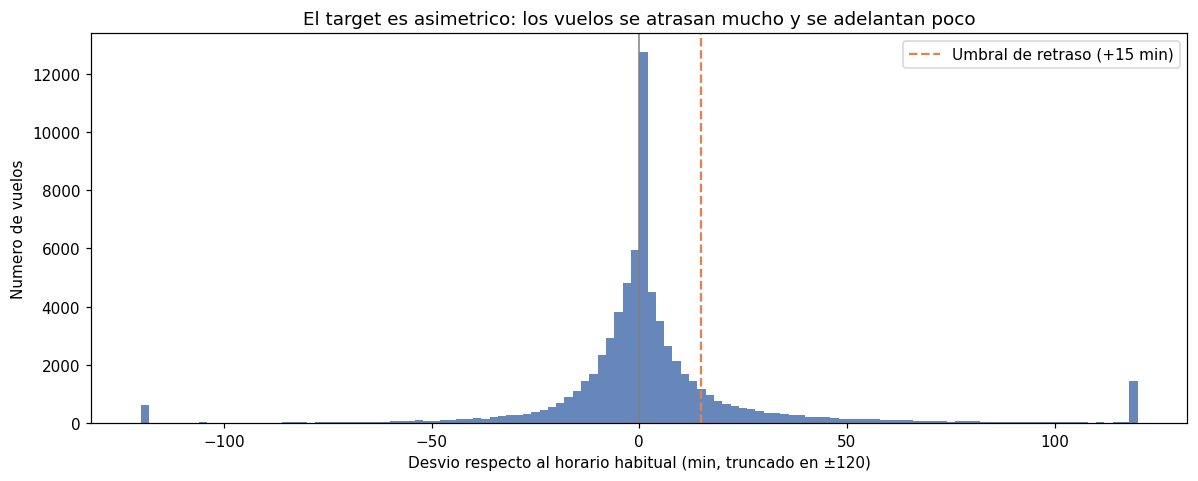

In [9]:
desvio = vuelos_target.desvio_min
percentiles = desvio.quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(1)
print("Distribucion del desvio respecto al horario habitual (minutos):")
print(percentiles.to_string())
print(f"\nDesviacion estandar: {desvio.std():.1f} min")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(desvio.clip(-120, 120), bins=120, color="#4C72B0", alpha=0.85)
ax.axvline(0, color="grey", linestyle="-", linewidth=1)
ax.axvline(PARAMS["umbral_retraso_min"], color="#DD8452", linestyle="--",
           label=f"Umbral de retraso (+{PARAMS['umbral_retraso_min']} min)")
ax.set_xlabel("Desvio respecto al horario habitual (min, truncado en ±120)")
ax.set_ylabel("Numero de vuelos")
ax.set_title("El target es asimetrico: los vuelos se atrasan mucho y se adelantan poco")
ax.legend()
fig.tight_layout()
mostrar(fig)

**Lo que confirma el grafico:** la distribucion esta centrada en cero, la cola izquierda es corta (p05 = −29 min, plausible) y la cola derecha es larga (p95 = +52 min).

**Esa asimetria es la firma de un retraso real.** Si la medida fuera ruido de medicion, seria simetrica.

## 3.3 Clima y cruce

El clima diario se limpia, se descartan las columnas 100% vacias para esta estacion (`snow`, `wpgt`, `tsun`) y se deriva el **viento cruzado**: un viento de 40 km/h alineado con la pista casi no molesta, el mismo viento de costado si. El Tepual tiene pista 17/35 (rumbo 170°).

El cruce es un LEFT JOIN por un solo campo, `fecha_cruce` (`YYYY-MM-DD`), justamente para que sea barato en memoria.

In [10]:
from operaciones_aeronaves.pipelines.retrasos_ml.nodes import cruzar_vuelos_clima, preparar_clima_scte

clima_raw = pd.read_csv(RAIZ / "data/01_raw/clima_diario_scte.csv", parse_dates=["fecha"])
clima = preparar_clima_scte(clima_raw, PARAMS)

vuelos_clima = cruzar_vuelos_clima(vuelos_target, clima)

print(f"Dias de clima            : {len(clima):,}")
print(f"Vuelos tras el cruce     : {len(vuelos_clima):,}")
print(f"Vuelos sin clima asociado: {vuelos_clima.tavg.isna().sum()}")
print()
display(clima.head(3))

                    INFO     Columnas de clima 100% vacias, descartadas: snow, wpgt, tsun              ]8;id=967613;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=143417;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#221\221]8;;\

                    INFO     Clima preparado: 2192 dias (2020-01-01 a 2025-12-31)                      ]8;id=316146;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=320918;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#240\240]8;;\

                    INFO     Cruce: 71606 vuelos | 0.00% sin clima                                     ]8;id=344307;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=438801;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#250\250]8;;\

Dias de clima            : 2,192
Vuelos tras el cruce     : 71,606
Vuelos sin clima asociado: 0



,fecha_cruce,tavg,tmin,tmax,amplitud_termica,prcp,dia_lluvioso,wspd,wdir,viento_cruzado,viento_frontal,pres
0,2020-01-01,15.7,8.0,22.0,14.0,0.0,0,13.7,188.0,4.233533,13.029474,1013.8
1,2020-01-02,17.3,9.6,24.2,14.6,0.0,0,11.3,202.0,5.988088,9.582943,1016.6
2,2020-01-03,18.1,13.9,25.0,11.1,0.0,0,11.8,231.0,10.320513,5.720754,1019.3


---

# Fase 4 — Modelado

El experimento central: cada modelo se entrena **tres veces** — solo con variables de operacion, solo con clima, y con ambas. Si sumar el clima no mueve el AUC, el clima no explica el retraso.

**El split es temporal, no aleatorio.** Un split aleatorio pondria vuelos del mismo dia en entrenamiento y prueba, y el modelo veria el clima de un dia que ya conoce.

| Tramo | Periodo | Para que |
|---|---|---|
| Entrenamiento | 2020-2023 | Aprender |
| Validacion | 2024 | Elegir modelo e hiperparametros |
| **Prueba** | **2025+** | Se toca **una sola vez** |

### Que dos algoritmos, y por que

| Algoritmo | Por que entra |
|---|---|
| **HistGradientBoosting** | El estandar para datos tabulares: captura interacciones no lineales sin pedir escalado ni codificacion, y maneja nulos de forma nativa |
| **Regresion Logistica** | Contraparte deliberadamente simple. **Si un modelo lineal iguala al boosting, es señal de que no hay estructura no lineal que aprender.** Ademas entrega probabilidades calibradas, que es lo que necesita un score leido como porcentaje |

La configuracion **no se elige a ojo**: se evaluan 30 combinaciones (6 del boosting y 4 de la logistica, por cada uno de los 3 conjuntos de variables), cada una ajustada con el tramo de entrenamiento y puntuada contra 2024.

In [11]:
from operaciones_aeronaves.pipelines.retrasos_ml.nodes import train_modelo_retrasos

metricas, busqueda, artefacto = train_modelo_retrasos(vuelos_clima, PARAMS)

print(f"Configuraciones evaluadas: {len(busqueda)}")

columnas = ["features", "modelo", "roc_auc_train", "roc_auc_val", "roc_auc",
            "average_precision", "lift_vs_azar", "brier", "seleccionado"]
display(metricas[columnas].style.hide(axis="index"))

                    INFO     Split temporal: train 42067 (<2024) | val 14850 (2024) | test 14689       ]8;id=805664;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=523667;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#387\387]8;;\
                             (>=2025)                                                                              

[09/24/26 19:24:00] INFO     Busqueda de hiperparametros: 30 configuraciones evaluadas                 ]8;id=299494;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=383685;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#435\435]8;;\

                    INFO     Mayor sobreajuste observado: GradientBoosting (max_iter=300,              ]8;id=865355;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=815493;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#437\437]8;;\
                             learning_rate=0.06, max_depth=6, min_samples_leaf=20,                                 
                             l2_regularization=0.0, early_stopping=False) — AUC train 0.8446 vs val                
                             0.5177                                                                                

                    INFO     Modelo elegido por validacion 2024: GradientBoosting sobre 'solo          ]8;id=411390;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=754633;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#453\453]8;;\
                             operacion' | AUC val 0.5691 -> test 0.5239                                            

                    INFO     Comparacion de conjuntos de features (ROC-AUC en test):                   ]8;id=364256;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=317238;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#455\455]8;;\
                             modelo             GradientBoosting  RegresionLogistica                               
                             features                                                                              
                             clima + operacion            0.5128              0.5184                               
                             solo clima                   0.4691              0.4862                               
                             solo operacion               0.5239              0.5330                               

Configuraciones evaluadas: 30


features,modelo,roc_auc_train,roc_auc_val,roc_auc,average_precision,lift_vs_azar,brier,seleccionado
solo operacion,GradientBoosting,0.637300,0.569100,0.523900,0.154900,1.121000,0.119900,True
solo operacion,RegresionLogistica,0.555100,0.540100,0.533000,0.156900,1.135000,0.119400,False
solo clima,GradientBoosting,0.565200,0.510200,0.469100,0.130000,0.941000,0.119400,False
solo clima,RegresionLogistica,0.525200,0.520200,0.486200,0.136000,0.984000,0.119500,False
clima + operacion,GradientBoosting,0.604200,0.544800,0.512800,0.151400,1.095000,0.119200,False
clima + operacion,RegresionLogistica,0.558300,0.537400,0.518400,0.152000,1.100000,0.119500,False


### Por que el modelo final esta fuertemente regularizado

La tabla siguiente es la justificacion de la configuracion elegida. La version flexible del boosting — con la que cualquiera empezaria — memoriza el ruido de 2020-2023 y no lo sostiene en 2024.

In [12]:
gb = busqueda[
    (busqueda.algoritmo == "GradientBoosting")
    & (busqueda.features == "clima + operacion")
]
display(gb[["config", "roc_auc_train", "roc_auc_val", "brecha_sobreajuste"]]
        .style.hide(axis="index"))

peor = gb.loc[gb.brecha_sobreajuste.idxmax()]
print(f"Mayor sobreajuste: AUC {peor.roc_auc_train:.4f} en entrenamiento "
      f"contra {peor.roc_auc_val:.4f} en validacion "
      f"(brecha {peor.brecha_sobreajuste:.4f})")

config,roc_auc_train,roc_auc_val,brecha_sobreajuste
"max_iter=300, learning_rate=0.06, max_depth=6, min_samples_leaf=20, l2_regularization=0.0, early_stopping=False",0.844600,0.517700,0.326900
"max_iter=150, learning_rate=0.05, max_depth=4, min_samples_leaf=50, l2_regularization=1.0, early_stopping=False",0.706300,0.537800,0.168600
"max_iter=100, learning_rate=0.05, max_depth=3, min_samples_leaf=100, l2_regularization=1.0, early_stopping=False",0.646200,0.541400,0.104800
"max_iter=60, learning_rate=0.05, max_depth=2, min_samples_leaf=200, l2_regularization=1.0, early_stopping=False",0.604200,0.544800,0.059400
"max_iter=40, learning_rate=0.03, max_depth=2, min_samples_leaf=500, l2_regularization=5.0, early_stopping=False",0.587000,0.543700,0.043300
"max_iter=25, learning_rate=0.05, max_depth=2, min_samples_leaf=1000, l2_regularization=10.0, early_stopping=False",0.587100,0.544500,0.042600


Mayor sobreajuste: AUC 0.8446 en entrenamiento contra 0.5177 en validacion (brecha 0.3269)


**La brecha de 0.33 es memorizacion pura.** A medida que se restringe la profundidad y se exige mas observaciones por hoja, el AUC de entrenamiento cae y el de validacion **sube**. Ese es el argumento — con evidencia — para responder a "¿por que su modelo es tan simple?".

### Tres lecturas, todas incomodas y todas honestas

1. **Con solo clima el modelo queda por debajo del azar** (AUC < 0.5). El clima diario, por si solo, no contiene informacion util sobre si un vuelo se retrasara.
2. **Agregar clima a las variables operativas empeora el modelo.** No es un error de codigo: es el comportamiento tipico de una variable que aporta ruido en vez de señal.
3. **El mejor modelo apenas supera el azar.** El pipeline selecciona automaticamente el ganador por el año de validacion, y **el ganador no usa clima.**

In [13]:
print(f"Modelo seleccionado: {artefacto['nombre_modelo']}")
print(f"Conjunto de features: {artefacto['conjunto_features']}")
print(f"\nVariables que efectivamente usa:\n  {artefacto['features']}")

Modelo seleccionado: GradientBoosting
Conjunto de features: solo operacion

Variables que efectivamente usa:
  ['hora_programada', 'dia_semana', 'mes', 'anio', 'aerolinea_cod', 'tipo_operacion_cod', 'modelo_cod', 'es_internacional']


---

# Fase 5 — Evaluacion

## 5.1 ¿Cuanto retrasa realmente el clima?

In [14]:
from operaciones_aeronaves.pipelines.retrasos_ml.nodes import evaluar_impacto_clima

efecto = evaluar_impacto_clima(vuelos_clima, artefacto)
display(efecto.style.hide(axis="index"))

[09/24/26 19:24:03] INFO     Guardado images\rt_01_clima_vs_retraso.png                                ]8;id=822452;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=817863;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#604\604]8;;\

                    INFO     Guardado images\rt_02_importancia.png                                     ]8;id=70255;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=470057;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#619\619]8;;\

[09/24/26 19:24:04] INFO     Guardado images\rt_03_hora_del_dia.png                                    ]8;id=212316;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=579464;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#638\638]8;;\

                    INFO     Guardado images\rt_04_roc_calibracion.png                                 ]8;id=591470;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=555406;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#685\685]8;;\

                    INFO     Guardado images\rt_08_busqueda_hiperparametros.png                        ]8;id=194003;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=69182;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#554\554]8;;\

                    INFO     Efecto del clima sobre el retraso:                                        ]8;id=268059;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py\nodes.py]8;;\:]8;id=415779;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\nodes.py#702\702]8;;\
                                       variable      rango  n_vuelos  tasa_retraso  puntos_vs_base                 
                                      lluvia_mm Sin lluvia     40602        0.1514           -0.05                 
                                      lluvia_mm     0-1 mm      9377        0.1438           -0.82                 
                                      lluvia_mm     1-5 mm     10165        0.1586            0.66                 
                                      lluvia_mm    5-15 mm      8117        0.1557            0.38                 
                                      lluvia_mm    > 15 mm      3345        0.1519           -0.01                 
                             viento_cruzado_kmh        < 5     32583        0.1465           -0.54                 
                             viento_cruzado_kmh       5-10     28831        0.1526            0.07                 
                             viento_cruzado_kmh      10-20      9064        0.1655            1.35                 
                             viento_cruzado_kmh      20-30       947        0.1668            1.49                 
                             viento_cruzado_kmh       > 30       181        0.2597           10.77                 

variable,rango,n_vuelos,tasa_retraso,puntos_vs_base
lluvia_mm,Sin lluvia,40602,0.151400,-0.050000
lluvia_mm,0-1 mm,9377,0.143800,-0.820000
lluvia_mm,1-5 mm,10165,0.158600,0.660000
lluvia_mm,5-15 mm,8117,0.155700,0.380000
lluvia_mm,> 15 mm,3345,0.151900,-0.010000
viento_cruzado_kmh,< 5,32583,0.146500,-0.540000
viento_cruzado_kmh,5-10,28831,0.152600,0.070000
viento_cruzado_kmh,10-20,9064,0.165500,1.350000
viento_cruzado_kmh,20-30,947,0.166800,1.490000
viento_cruzado_kmh,> 30,181,0.259700,10.770000


**La lluvia no retrasa vuelos en Puerto Montt.** Un dia con mas de 15 mm tiene practicamente la misma tasa de retraso que un dia seco. La explicacion es operativa: **en Puerto Montt llueve el 44.9% de los dias** — un aeropuerto que opera bajo lluvia casi la mitad del año esta diseñado y entrenado para la lluvia. Ahi la lluvia no es una anomalia, es la condicion normal.

**El viento cruzado si retrasa, pero solo en el extremo.** Sobre 30 km/h perpendicular a la pista la tasa **casi se duplica** (14.7% → 26.0%). Tiene sentido fisico: es el viento de costado, no la lluvia, lo que limita un aterrizaje.

**Pero ese escenario ocurre en 181 de 71 606 vuelos: el 0.25%.** Demasiado raro para que un modelo lo aproveche — y ahi esta la clave de todo el proyecto.


Efecto del clima sobre la tasa de retraso


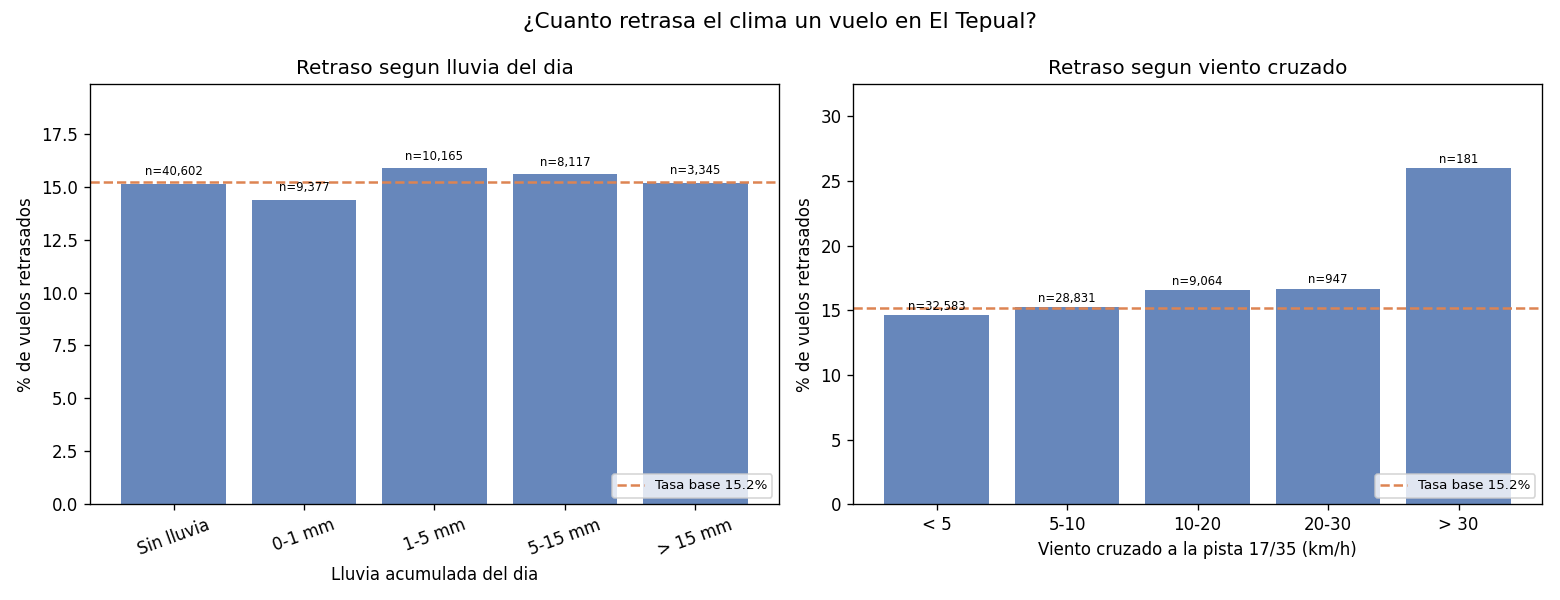


Que mueve el riesgo: clima vs operacion


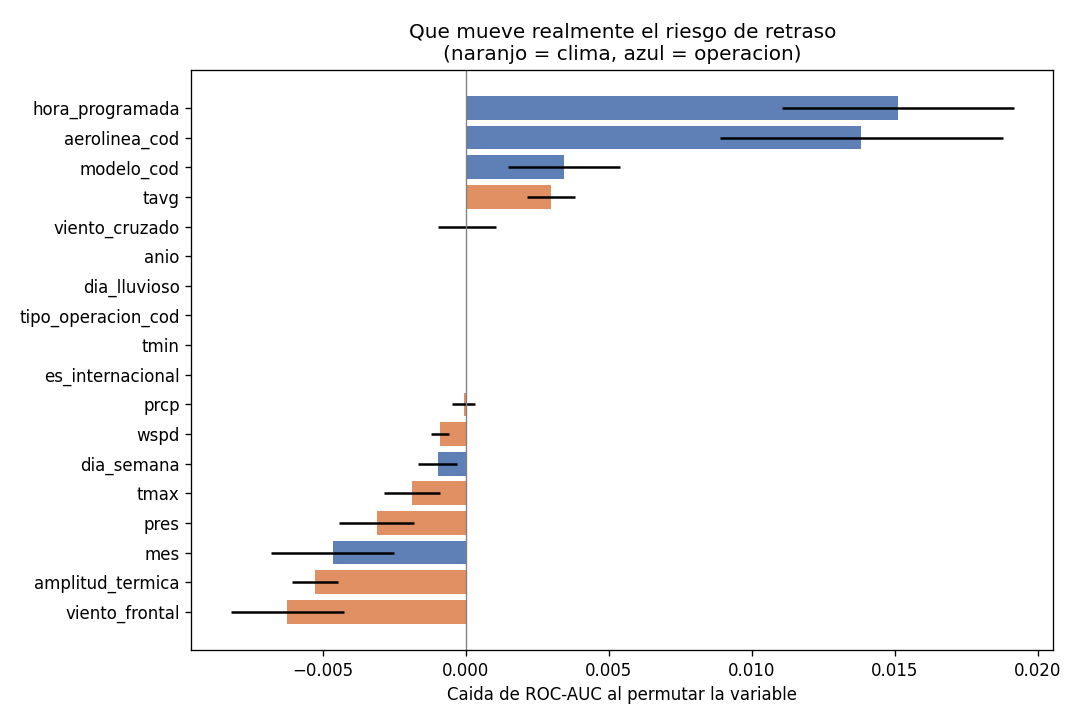


Propagacion del retraso durante el dia


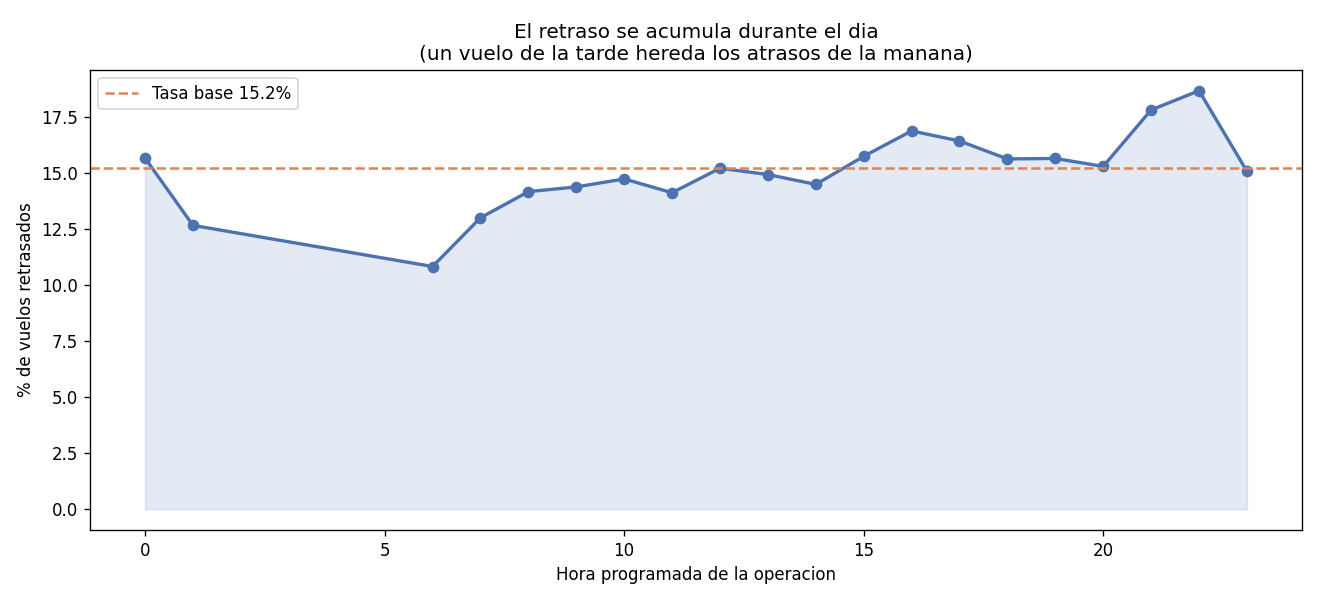


Discriminacion y calibracion del Score de Riesgo


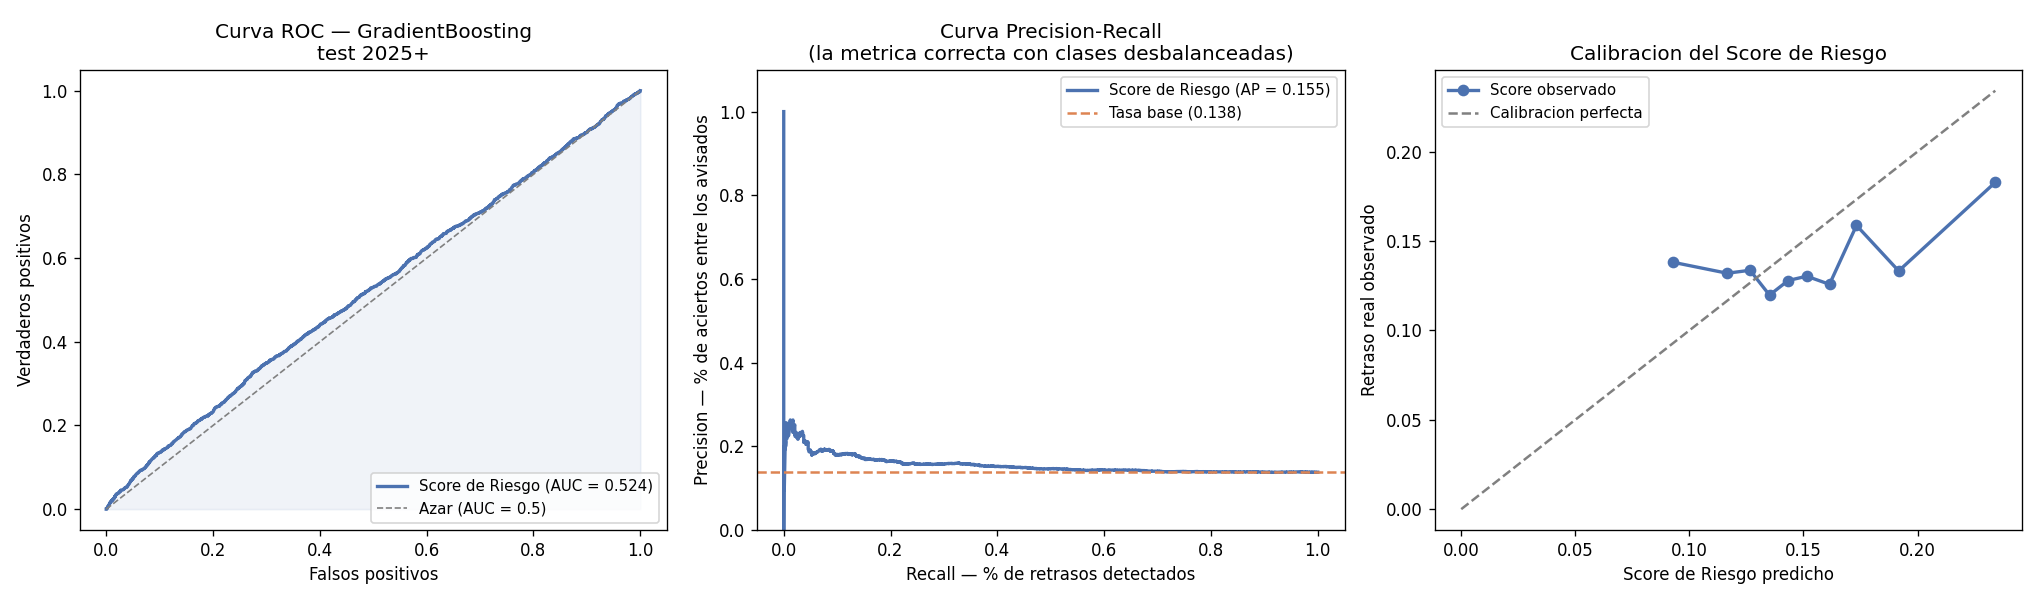

In [15]:
for nombre, titulo in [
    ("rt_01_clima_vs_retraso.png", "Efecto del clima sobre la tasa de retraso"),
    ("rt_02_importancia.png", "Que mueve el riesgo: clima vs operacion"),
    ("rt_03_hora_del_dia.png", "Propagacion del retraso durante el dia"),
    ("rt_04_roc_calibracion.png", "Discriminacion y calibracion del Score de Riesgo"),
]:
    print(f"\n{titulo}")
    display(Image(filename=str(RAIZ / "images" / nombre)))

**Importancia por permutacion (grafico 2):** las unicas dos variables con aporte real son la **hora programada** y la **aerolinea** — ambas operativas. Las de clima estan pegadas a cero o en negativo.

**Propagacion (grafico 3):** un vuelo programado a las 06:00 tiene 10.8% de riesgo; uno de las 22:00, 18.7%. El avion de la tarde hereda los atrasos de la mañana. **Es propagacion de red, no clima.**

**Calibracion (grafico 4):** todos los scores del modelo caben entre 13.5% y 19%. El modelo predice casi la tasa base para todos los vuelos, porque no encontro nada que le permita distinguirlos. Esta bien calibrado, y es casi inutil para decidir.

---

## 5.3 Aprendizaje no supervisado sobre el mismo problema

Hasta aqui todo fue supervisado. Ahora se ataca el problema **sin etiquetas**, por dos vias que responden preguntas distintas:

1. **Segmentar vuelos** por su comportamiento operativo → *¿que vuelos concentran el riesgo?*
2. **Segmentar dias** por sus condiciones, sin mirar el resultado → *¿existe un arquetipo de dia malo?*

### Como se elige k, y por que no basta el silhouette

Se recorre k = 2 a 8 y se elige por silhouette, **pero con una condicion de tamano: ningun grupo puede quedar bajo el 2% del total**. El silhouette por si solo premia particiones que aislan un puñado de casos raros: compactas en lo matematico, inutiles para decidir.

In [16]:
from operaciones_aeronaves.pipelines.retrasos_ml.segmentacion import (
    perfilar_vuelos,
    segmentar_dias,
    segmentar_vuelos,
)

perfil = perfilar_vuelos(vuelos_clima, PARAMS)
segmentos, artefacto_seg = segmentar_vuelos(perfil, PARAMS)

print(f"k elegido: {artefacto_seg['k']}")
display(artefacto_seg["diagnostico_k"].style.hide(axis="index"))

                    INFO     Perfil de vuelos: 253 slots con >= 30 operaciones (de 472); cubren ]8;id=973385;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=178387;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#143\143]8;;\
                             69103 vuelos                                                                          

[09/24/26 19:24:05] INFO     k elegido = 5                                                       ]8;id=783434;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=383764;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#82\82]8;;\
                              k  inercia  silhouette  cluster_mas_chico_pct  admisible  elegido                    
                              2   929.30      0.2741                 0.3320       True    False                    
                              3   740.80      0.2572                 0.0988       True    False                    
                              4   586.30      0.2862                 0.0711       True    False                    
                              5   489.51      0.3017                 0.0672       True     True                    
                              6   417.83      0.3101                 0.0158      False    False                    
                              7   371.99      0.3008                 0.0158      False    False                    
                              8   344.62      0.2867                 0.0158      False    False                    

                    INFO     Guardado images\rt_05_seleccion_k_vuelos.png                       ]8;id=524100;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=335326;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#110\110]8;;\

                    INFO     Segmentos de vuelo:                                                ]8;id=581253;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=780922;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#203\203]8;;\
                              segmento  n_slots  vuelos_cubiertos  hora_media  tasa_retraso                        
                             variabilidad_min  pct_severo                                                          
                                     3       17              3904      15.177         0.257                        
                             32.985       0.118                                                                    
                                     1       62              5815      12.310         0.176                        
                             14.260       0.066                                                                    
                                     2       42              3731      18.474         0.165                        
                             14.586       0.029                                                                    
                                     4       63             49148      14.648         0.143                        
                             12.139       0.035                                                                    
                                     0       69              6505      12.259         0.100                        
                             9.393       0.020                                                                     

                    INFO     Segmento critico: 17 slots (6.7% de los slots) que concentran 5.6% ]8;id=354369;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=188420;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#206\206]8;;\
                             de los vuelos con una tasa de retraso de 25.7% (base 15.1%)                           

                    INFO     Guardado images\rt_06_segmentos_vuelos.png                         ]8;id=664077;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=141951;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#270\270]8;;\

k elegido: 5


k,inercia,silhouette,cluster_mas_chico_pct,admisible,elegido
2,929.300000,0.274100,0.332000,True,False
3,740.800000,0.257200,0.098800,True,False
4,586.300000,0.286200,0.071100,True,False
5,489.510000,0.301700,0.067200,True,True
6,417.830000,0.310100,0.015800,False,False
7,371.990000,0.300800,0.015800,False,False
8,344.620000,0.286700,0.015800,False,False


El maximo silhouette esta en **k=6**, pero su grupo mas chico reune solo el 1.6% de los slots — un cluster de 4 vuelos sobre el que nadie va a tomar una decision. La regla lo descarta y elige **k=5**, donde el grupo mas chico ya reune el 6.7%.

In [17]:
display(artefacto_seg["resumen"].round(3).style.hide(axis="index"))

criticos = segmentos[segmentos.es_segmento_critico == 1]
print(f"Segmento critico: {len(criticos)} slots de {len(segmentos)} "
      f"({len(criticos)/len(segmentos):.1%} de los slots)")
print(f"Concentran {criticos.n_operaciones.sum():,} vuelos "
      f"({criticos.n_operaciones.sum()/segmentos.n_operaciones.sum():.1%} de las operaciones)")
print(f"Tasa de retraso: {criticos.tasa_retraso.mean():.1%} contra "
      f"{segmentos.tasa_retraso.mean():.1%} de media global")

segmento,n_slots,vuelos_cubiertos,hora_media,tasa_retraso,variabilidad_min,pct_severo
3,17,3904,15.177000,0.257000,32.985000,0.118000
1,62,5815,12.310000,0.176000,14.260000,0.066000
2,42,3731,18.474000,0.165000,14.586000,0.029000
4,63,49148,14.648000,0.143000,12.139000,0.035000
0,69,6505,12.259000,0.100000,9.393000,0.020000


Segmento critico: 17 slots de 253 (6.7% de los slots)
Concentran 3,904 vuelos (5.6% de las operaciones)
Tasa de retraso: 25.7% contra 15.1% de media global


**El hallazgo accionable: 17 slots — el 5.6% de las operaciones — tienen una tasa de retraso de 25.7%, mas del doble que el segmento mas puntual.** No hace falta intervenir todo El Tepual: hace falta intervenir 17 vuelos.

Y el contraste entre el mejor y el peor segmento senala donde esta el problema: **no es la hora** (12:16 contra 15:10, ambos en horario normal) sino la **variabilidad**, que pasa de ±9 a ±33 minutos. El segmento critico no llega tarde de forma sistematica: es impredecible, que operativamente es peor.

> **Advertencia antes de usar esta tabla.** 13 de los 17 slots criticos son de una misma aerolinea, pero eso **no** significa que sea la menos puntual: el target mide desviacion respecto del horario habitual *de cada vuelo*, asi que penaliza la irregularidad y no el atraso cronico. Sirve para priorizar donde poner buffer operativo, no para comparar aerolineas entre si.

### Via 2 — ¿Existe un arquetipo de dia malo?

Aqui el diseño es distinto, y por eso el resultado **si** constituye una prueba: los dias se agrupan **solo por sus condiciones** — carga operativa, lluvia, viento, temperatura, presion. La puntualidad no entra al clustering; se usa despues, unicamente para etiquetar los grupos ya formados.

Si las condiciones contuvieran informacion sobre el retraso, los grupos formados solo con ellas deberian separarse tambien en puntualidad.

In [18]:
dias = segmentar_dias(vuelos_clima, PARAMS)

resumen_dias = dias.groupby("tipo_dia").agg(
    dias=("tasa_retraso", "size"),
    lluvia_mm=("prcp", "mean"),
    viento_cruzado=("viento_cruzado", "mean"),
    operaciones=("n_operaciones", "mean"),
    tasa_retraso=("tasa_retraso", "mean"),
).round(3)
display(resumen_dias)

[09/24/26 19:24:06] INFO     k elegido = 2                                                       ]8;id=99747;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=431679;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#82\82]8;;\
                              k  inercia  silhouette  cluster_mas_chico_pct  admisible  elegido                    
                              2 13132.79      0.2362                 0.2650       True     True                    
                              3 11075.98      0.1781                 0.2328       True    False                    
                              4 10077.90      0.1829                 0.1040       True    False                    
                              5  9165.05      0.1790                 0.0936       True    False                    
                              6  8577.17      0.1512                 0.0852       True    False                    
                              7  8188.19      0.1450                 0.0778       True    False                    
                              8  7824.40      0.1503                 0.0545       True    False                    

[09/24/26 19:24:07] INFO     Brecha de puntualidad entre el mejor y el peor tipo de dia, por k: ]8;id=364092;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=159741;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#329\329]8;;\
                              k  brecha_puntos                                                                     
                              2           1.40                                                                     
                              3           1.87                                                                     
                              4           2.67                                                                     
                              5           2.51                                                                     
                              6           2.75                                                                     
                              7           3.09                                                                     
                              8           4.66                                                                     

                    INFO     La brecha nunca supera 4.7 puntos: agrupar los dias por sus        ]8;id=937947;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=605011;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#333\333]8;;\
                             condiciones no separa los dias buenos de los malos, sea cual sea                      
                             el numero de grupos.                                                                  

                    INFO     Tipos de dia (agrupados solo por condiciones):                     ]8;id=577846;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=225433;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#355\355]8;;\
                              tipo_dia  n_dias  operaciones  lluvia_mm  viento_cruzado                             
                             temperatura  tasa_retraso                                                             
                                     0    1484       35.611      0.604           4.938                             
                             10.611         0.150                                                                  
                                     1     535       33.787      7.946           9.034                             
                             9.869         0.164                                                                   

                    INFO     Diferencia de puntualidad entre el mejor y el peor tipo de dia:    ]8;id=912209;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=409694;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#357\357]8;;\
                             1.4 puntos. Si las condiciones explicaran el retraso, esta brecha                     
                             seria grande.                                                                         

                    INFO     Guardado images\rt_07_segmentos_dias.png                           ]8;id=127582;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py\segmentacion.py]8;;\:]8;id=589992;file://C:\Users\Arturo\Desktop\OperacionesAeronaves\src\operaciones_aeronaves\pipelines\retrasos_ml\segmentacion.py#410\410]8;;\

,dias,lluvia_mm,viento_cruzado,operaciones,tasa_retraso
tipo_dia,,,,,
0,1484,0.604,4.938,35.611,0.150
1,535,7.946,9.034,33.787,0.164


El algoritmo separa limpiamente los dos arquetipos que uno esperaria en Puerto Montt — el dia seco y calmo, y el lluvioso y ventoso. **Y difieren en solo 1.4 puntos de puntualidad.**

Cuantos perfiles de vuelo hay, y por que k=5


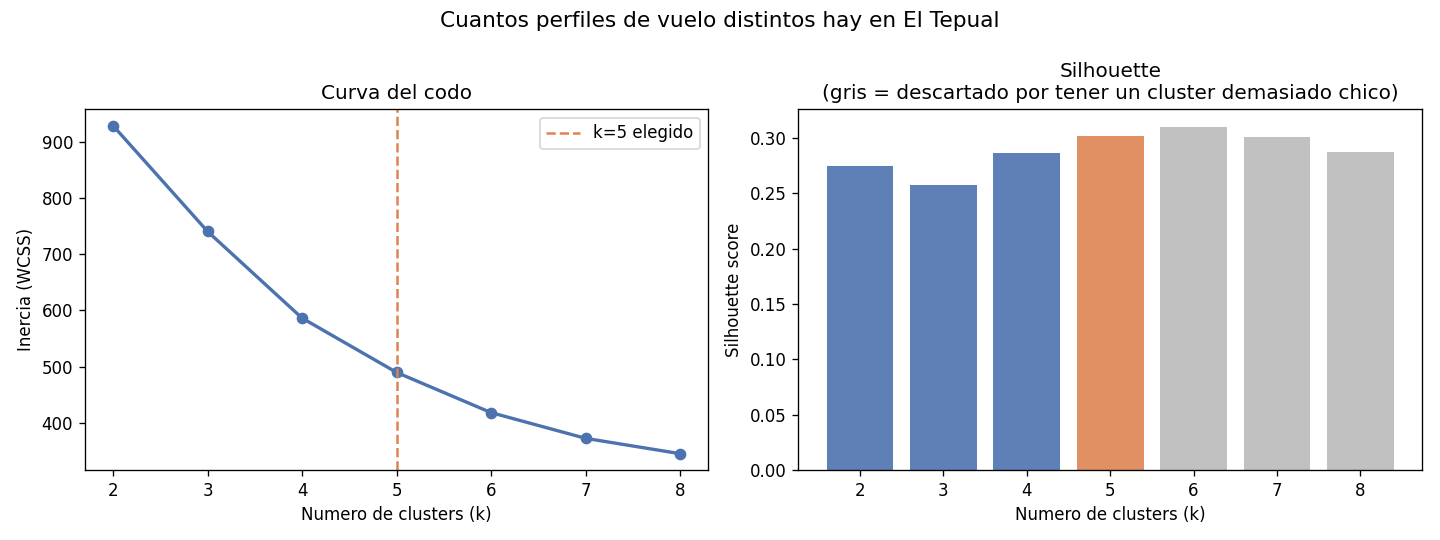

Que vuelos concentran el riesgo


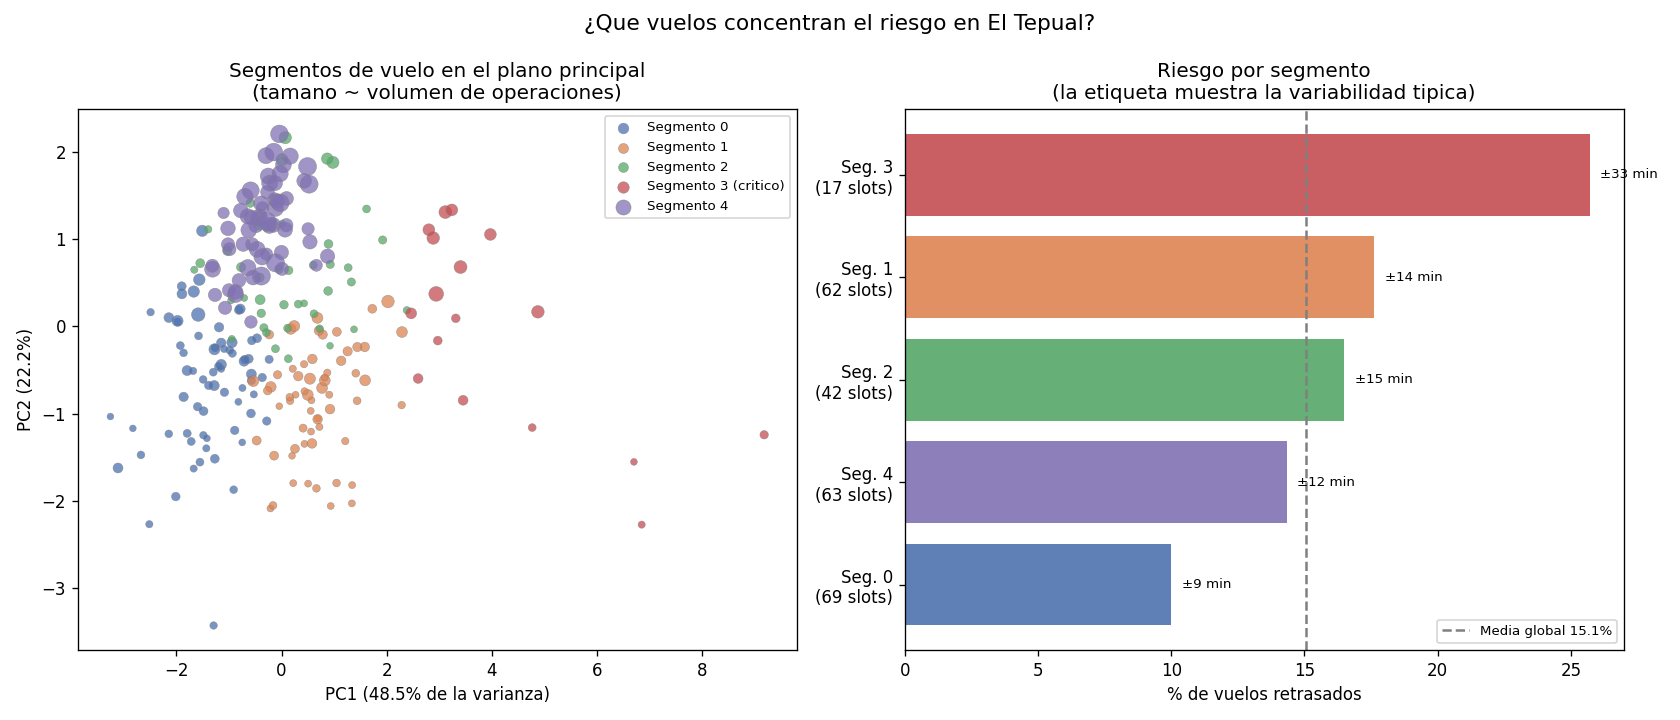

¿Existe un arquetipo de dia malo?


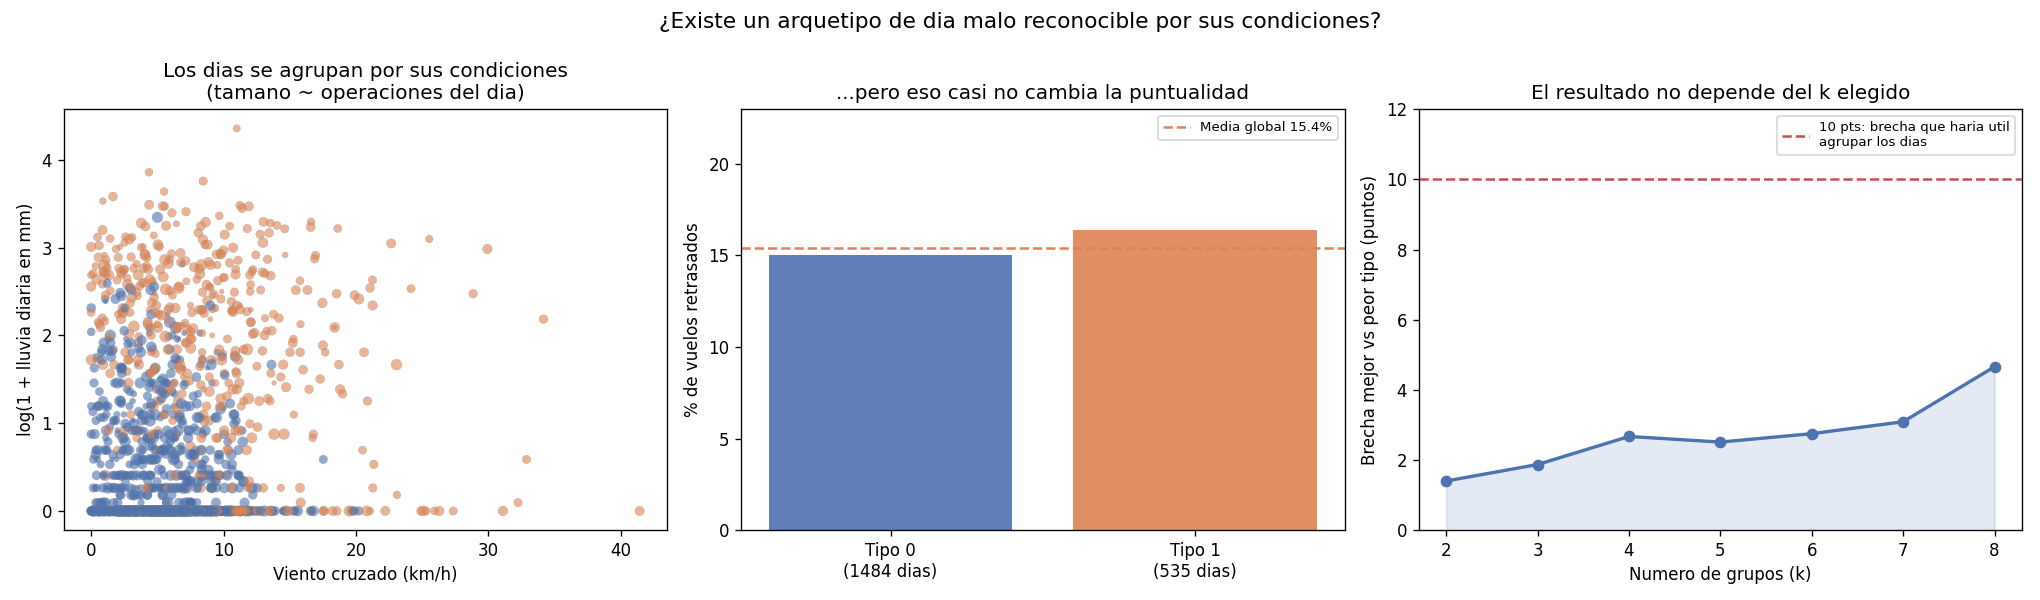

In [19]:
for nombre, titulo in [
    ("rt_05_seleccion_k_vuelos.png", "Cuantos perfiles de vuelo hay, y por que k=5"),
    ("rt_06_segmentos_vuelos.png", "Que vuelos concentran el riesgo"),
    ("rt_07_segmentos_dias.png", "¿Existe un arquetipo de dia malo?"),
]:
    print(titulo)
    display(Image(filename=str(RAIZ / "images" / nombre)))

El tercer panel del ultimo grafico cierra la objecion obvia — *"eligieron un k que les convenia"*: la brecha entre el mejor y el peor tipo de dia se midio para **todos** los k entre 2 y 8, y **nunca supera 4.7 puntos**. Para que agrupar los dias por sus condiciones fuera operativamente util, esa brecha tendria que rondar los 10 puntos.

**Las dos vias, supervisada y no supervisada, llegan al mismo lugar por caminos independientes.** El clima define con claridad como es un dia en El Tepual; no define si ese dia se va a retrasar.

## 5.2 Contraste contra los umbrales de la Fase 1

Este es el momento de la verdad: los umbrales se fijaron antes de modelar, y ahora se comparan sin negociar.

In [20]:
ganador = metricas[metricas.seleccionado].iloc[0]
auc_con_clima = metricas[metricas.features == "clima + operacion"].roc_auc.max()
auc_sin_clima = metricas[metricas.features == "solo operacion"].roc_auc.max()

evaluacion = pd.DataFrame([
    {"KPI": "Lift sobre la tasa base", "umbral": ">= 1.50",
     "obtenido": round(ganador.lift_vs_azar, 3), "cumple": ganador.lift_vs_azar >= 1.50},
    {"KPI": "ROC-AUC en datos futuros", "umbral": ">= 0.65",
     "obtenido": round(ganador.roc_auc, 4), "cumple": ganador.roc_auc >= 0.65},
    {"KPI": "Brier score (calibracion)", "umbral": "<= 0.13",
     "obtenido": round(ganador.brier, 4), "cumple": ganador.brier <= 0.13},
    {"KPI": "Aporte del clima al AUC", "umbral": "> 0",
     "obtenido": round(auc_con_clima - auc_sin_clima, 4),
     "cumple": (auc_con_clima - auc_sin_clima) > 0},
])
evaluacion["resultado"] = np.where(evaluacion.cumple, "CUMPLE", "NO CUMPLE")
display(evaluacion[["KPI", "umbral", "obtenido", "resultado"]].style.hide(axis="index"))

print(f"\nKPIs cumplidos: {evaluacion.cumple.sum()} de {len(evaluacion)}")

KPI,umbral,obtenido,resultado
Lift sobre la tasa base,>= 1.50,1.121000,NO CUMPLE
ROC-AUC en datos futuros,>= 0.65,0.523900,NO CUMPLE
Brier score (calibracion),<= 0.13,0.119900,CUMPLE
Aporte del clima al AUC,> 0,-0.014600,NO CUMPLE



KPIs cumplidos: 1 de 4


---

# Fase 6 — Despliegue: la decision de NO desplegar

**Tres de los cuatro KPIs no se cumplen.** El unico que pasa es la calibracion: el modelo es honesto sobre su propia incertidumbre, pero esa incertidumbre es demasiado alta para decidir con ella.

**Decision: el modelo de retrasos NO se despliega.** Queda serializado en `data/06_models/modelo_retrasos.pkl` como evidencia reproducible del experimento, no como producto.

### Lo que si se recomienda al negocio

Dado que el efecto del clima se concentra en un extremo raro pero severo, la accion rentable **no es un modelo predictivo, es un umbral**:

> **Cuando el pronostico indique viento cruzado sobre 30 km/h en El Tepual, activar el protocolo de contingencia.**

Eso captura casi todo el valor del clima sin la infraestructura, el mantenimiento ni el riesgo de un modelo que apenas supera el azar.

### Ventana de confianza

Si en el futuro el modelo mejora, su score solo sera confiable en una ventana de **7 a 14 dias**: mas alla, el concept drift, la degradacion del pronostico meteorologico y la falta de firmeza del itinerario hacen que el margen de error sea inaceptable para una decision gerencial.

---

## Consideraciones eticas — resumen

| Aspecto | Sintesis |
|---|---|
| **Privacidad** | La bitacora no tiene datos de pasajeros, pero `matricula` identifica aeronaves rastreables hasta su dueño via el registro publico de la DGAC. El pipeline filtra a aviacion comercial regular y **excluye la matricula de todas las features** |
| **Sesgo de seleccion** | Los operadores pequeños pierden hasta 1 de cada 5 vuelos al exigir 3 observaciones por grupo. El modelo representa peor a quien menos vuela |
| **Sesgo del target** | Una aerolinea cronicamente atrasada aparece como puntual, porque su atraso queda incorporado en su horario "habitual". **No sirve para comparar aerolineas entre si** |
| **Sesgo COVID** | 2020 opero a menos de la mitad del volumen de 2024; son dos regimenes distintos tratados como uno |
| **Uso punitivo** | Con AUC 0.534, cualquier decision laboral basada en este score seria azar con apariencia de objetividad |

El detalle completo esta en la seccion [Etica, sesgos y privacidad](../README.md#etica-sesgos-y-privacidad) del README.

---

## Conclusion

El valor de este proyecto no esta en haber construido un modelo que funciona. Esta en **haber medido bien algo que resulto no funcionar**, y en haberlo documentado en vez de maquillarlo.

Habia un camino alternativo: usar un split aleatorio en vez de temporal, reportar las metricas notablemente mejores que eso habria dado, y presentar un modelo exitoso. Habrian sido cifras falsas, porque el modelo habria visto vuelos del mismo dia en entrenamiento y prueba. Se eligio el camino correcto.

In [21]:
session.close()
print("Notebook ejecutado completo.")

Notebook ejecutado completo.
